In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## Data Analysis

In [2]:
data = pd.read_csv("/content/Ames_Housing_Project.csv")

# ============================== Data Analysis ================================

print("Top 10 House Data: \n",data.head(10))

print("\nNumber of Houses: \n",data.shape[0])
print("Number of Features: \n",data.shape[1])

print("\nChecking Data Type Stored in each feature: ")
print(data.info())


Top 10 House Data: 
    Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   
5      6  527105030           60        RL          78.0      9978   Pave   
6      7  527127150          120        RL          41.0      4920   Pave   
7      8  527145080          120        RL          43.0      5005   Pave   
8      9  527146030          120        RL          39.0      5389   Pave   
9     10  527162130           60        RL          60.0      7500   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN 

## Data Cleaning

In [3]:
# =============================== Data Cleaning ==============================

print("\nChecking for Nan/Missing value: \n",data.isnull().sum().sort_values(ascending = False).head(30))

# Updating Data
# Assigning Median value to Numeric datatype Columns
for val in data.select_dtypes(include = ["int","float"]):
   data[val] = data[val].fillna(data[val].median())

# Assigning None value to Object datatype Columns
for col in data.select_dtypes(include = "object"):
   data[col] = data[col].fillna("None")

print("Verifying for Nan/Missing Value: \n",data.isnull().sum().sum())

# We can not Dropping Nan/Missing value from dataset due to unnecessary loss of valuable data


print("\nChecking for Duplicate/Repeated value: \n",data.duplicated().sum())
# There was no Duplicate value in whole dataset



Checking for Nan/Missing value: 
 Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
Lot Shape            0
Street               0
Lot Area             0
dtype: int64
Verifying for Nan/Missing Value: 
 0

Checking for Duplicate/Repeated value: 
 0


## EDA(Exploratory Data Analysis) on "Sale Price"


IQR: 	 84000.0
Outliers(Extreme value): 
       Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
15       16  527216070           60        RL          47.0     53504   Pave   
17       18  527258010           20        RL          88.0     11394   Pave   
36       37  528108120           60        RL         102.0     12858   Pave   
38       39  528120060           20        RL          83.0     10159   Pave   
44       45  528150070           20        RL         100.0     12919   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2666   2667  902400110           75        RM          90.0     22950   Pave   
2737   2738  905427030           75        RL          60.0     19800   Pave   
2883   2884  911370430          120        RM          41.0      5748   Pave   
2901   2902  921205030           20        RL          88.0     11443   Pave   
2902   2903  921205050           20        RL          88.0     11577   Pave 

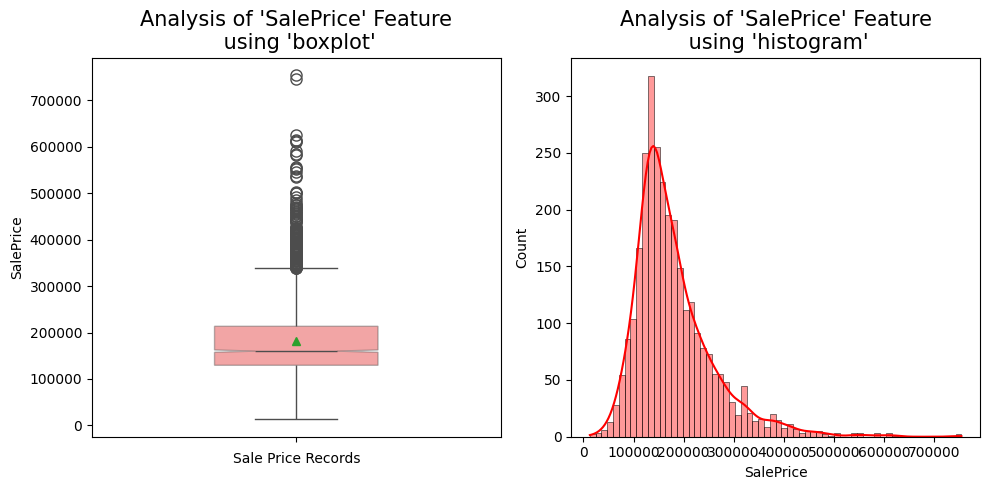


From Boxplot,
Number of Expensive House(Extreme Value): 	137

The Histogram showed that "Sale Feature" is in right skew manner,
which means most of houses price was low or moderate but there was few expensive houses also in data.
So, It make long tail in right side due to few expensive houses and rest there was normal-to- moderate houses price





In [4]:
# ============================ EDA(Exploratory Data Analysis) on "Sale Price" =========================

Q1 = data["SalePrice"].quantile(0.25)
Q3 = data["SalePrice"].quantile(0.75)

IQR = Q3-Q1
print("\nIQR: \t",IQR)

upper = Q3 + IQR*1.5
lower = Q1 - IQR*1.5

outlier = data[(data["SalePrice"] > upper) | (data["SalePrice"] < lower)]

print("Outliers(Extreme value): \n",outlier,"\n")



plt.figure(figsize = (10,5))
plt.subplot(1,2,1)

plt.title("Analysis of 'SalePrice' Feature\n using 'boxplot'",fontsize = 15)
plt.xlabel("Sale Price Records")

sns.boxplot(y = "SalePrice",data = data,color = "red",width = 0.4,boxprops = dict(alpha = 0.4),showmeans = True,notch = True,fliersize = 8)

plt.subplot(1,2,2)

plt.title("Analysis of 'SalePrice' Feature\n using 'histogram'",fontsize = 15)

sns.histplot(x = "SalePrice",data = data,kde = True,edgecolor = "black",color = "red",alpha = 0.4,stat = "count")

plt.tight_layout()
plt.show()



print(f"""
From Boxplot,
Number of Expensive House(Extreme Value): \t{outlier.shape[0]}

The Histogram showed that "Sale Feature" is in right skew manner,
which means most of houses price was low or moderate but there was few expensive houses also in data.
So, It make long tail in right side due to few expensive houses and rest there was normal-to- moderate houses price
\n\n""")

# I hypothesize that SalePrice feature was depend on -> Year Built,Overall Cond,Kitchen Qual,
                                                    #   Pool Area,Garage Area.Full Bath,Gr Liv Area
                                                    #   Total Bsmt SF(Total area of basement),Fireplaces


## Analysis between 'SalePrice' and 'Overall Qual'

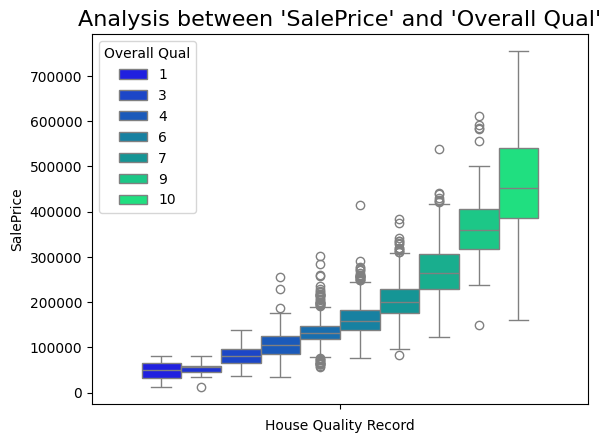


According to Data,
Most of the "high Sale" are coming from high quality houses.
Buyers can give "more Money" for high quality houses.
Buyers are not willing to buy low standard quality houses.



In [5]:
# ========================== Analysis between 'SalePrice' and 'Overall Qual' ===================================


plt.title("Analysis between 'SalePrice' and 'Overall Qual'",fontsize = 16)

plt.xlabel("House Quality Record")

sns.boxplot(y = "SalePrice",data = data,hue = "Overall Qual",palette = "winter",linecolor = "grey")

plt.show()

print("""
According to Data,
Most of the "high Sale" are coming from high quality houses.
Buyers can give "more Money" for high quality houses.
Buyers are not willing to buy low standard quality houses.
""")